# Entropy evolution in a random circuit and quantum depolarizing channel with Pauli Propagation and MPO

The goal of this notebook is to study the time evolution of a local quantum observable using the Pauli propagation framework implemented in `PauliPropagation.jl` and the MPO method in `ITensorMPS.jl`.

In [324]:
# using Pkg; Pkg.add("LaTeXStrings"); Pkg.add("PauliPropagation"); Pkg.add("ITensors"); Pkg.add("ITensorMPS")

In [325]:
using LaTeXStrings
using Plots
using LinearAlgebra
import Statistics: mean

# --- Pauli Propagation ---
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

# --- MPO ---
using ITensors, ITensorMPS

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

# --- Exact method ---
#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

# --- Circuit ---
#include("../src/circuit.jl")
include("circuit.jl")
import .circuit as ct

# 1. Introduction

Now we want to apply noise on the random bricklayer circuit.

## 1.1 The Noise

The single qubit **depolarizing channel**
$$N(\rho) = (1-\gamma)\rho + \frac{\mathbb I}{D} \gamma = \sum_i K_i \rho K_i^\dagger$$

We have the trace preserving condition cause of :
$$\sum_i K_i^\dagger K_i = \mathbb I$$


---

## 1.2 Pauli propagation

For the noisy circuits, we'll define a function `applynoiselayer`, which adds depolarizing and dephasing noise in the Pauli Transfer Matrix (PTM) formalism.

Note that the `depol_strength` (and `dephase_strength`) arguments in the `applynoiselayer` function are not simply the single gate error probabilites as one might assume, rather they are related to those via a multiplicative factor which depends on the noise kind. You can safely skip this section for now, but it will be useful if you are trying to implement a circuit with certain gate error probabilities.

---

## 1.3 MPO

`apply_depolarizing_noise(O::MPO, sites_to_noise::Vector{<:Index}, lambda::Float64; cutoff::Float64=1e-8, maxdim::Int=200)`

# 2. Quantities and measurement

In [326]:
nqubits = 5
nlayers = 50

# define the circuit
circuit_pp, circuit_mpo, circuit_exact, sites = ct.random_circuit(nqubits, nlayers)

# for Z_i
i= 2

2

### Exact

In [327]:
# Exact
Z_i_exact = ext.get_Zi(nqubits, i)

# Pauli Propagation
max_weight = nqubits
min_abs_coeff = 1e-5

Z_i_pp = PauliString(nqubits, :Z, i) # I...IZI...I

# MPO
cutoff = 1e-6
maxdim = 25

ops = ["Id" for n in 1:nqubits]
ops[i] = "Z"
Z_i_mpo = MPO(sites, ops)

5-element MPO:
 ((dim=2|id=204|"Qubit,Site,n=1")', (dim=2|id=204|"Qubit,Site,n=1"), (dim=1|id=521|"Link,l=1"))
 ((dim=2|id=771|"Qubit,Site,n=2")', (dim=2|id=771|"Qubit,Site,n=2"), (dim=1|id=350|"Link,l=2"), (dim=1|id=521|"Link,l=1"))
 ((dim=2|id=82|"Qubit,Site,n=3")', (dim=2|id=82|"Qubit,Site,n=3"), (dim=1|id=748|"Link,l=3"), (dim=1|id=350|"Link,l=2"))
 ((dim=2|id=809|"Qubit,Site,n=4")', (dim=2|id=809|"Qubit,Site,n=4"), (dim=1|id=650|"Link,l=4"), (dim=1|id=748|"Link,l=3"))
 ((dim=2|id=291|"Qubit,Site,n=5")', (dim=2|id=291|"Qubit,Site,n=5"), (dim=1|id=650|"Link,l=4"))

---

## 2.1 Rényi Entropy of an Observable

To quantify the **complexity** (or the "magic") of an observable, we can analyze its spread across the Pauli basis. Let us consider an observable $O$ decomposed as a sum of Pauli strings:
$$O = \sum_P c_P P$$

Given that the dimension of the Hilbert space is $D = 2^{n_{qubits}}$, we can use the orthogonality of Pauli matrices to express the exact coefficient for each string as:
$$c_P = \frac{Tr(OP)}{D}$$

To analyze this decomposition statistically, we treat the squared coefficients as a **probability distribution** $\pi(P)$ over the Pauli group. By normalizing these weights, we obtain:
$$\pi(P) = \frac{c_P^2}{\sum_Q c_Q^2} = \frac{Tr(OP)^2}{D Tr(O^2)}$$

**Proof:**
We can verify the denominator's equality by evaluating the trace of $O^2$. Expanding the product of the sums yields:
$$Tr(O^2) = Tr\left(\sum_P c_P P \sum_Q c_Q Q\right) = \sum_{P,Q} c_P c_Q Tr(PQ)$$
Because Pauli matrices are orthogonal, we know that $Tr(PQ) = D \delta_{P,Q}$ (the trace is $D$ when $P=Q$, and $0$ otherwise). This property collapses the double sum into a single sum:
$$Tr(O^2) = Tr\left(\sum_Q c_Q^2 \mathbb{I}\right) = D \sum_Q c_Q^2$$
By substituting this result and the initial definition of $c_P$ into the fraction, the relation is proven. $\square$

With this probability distribution established, we can compute its **$k$-th moments**, denoted as $\zeta_k$:
$$\zeta_k \equiv \sum_P \pi(P)^k = D^{-k}\sum_P \frac{Tr(OP)^{2k}}{Tr(O^2)^k} = D^{-2k+2}\mu_k \quad \text{with} \quad \mu_k = \sum_P \frac{Tr(OP)^{2k}}{D^{2-k}Tr(O^2)^k}$$

Finally, using these moments, we can define the **Rényi entropy** of order $k$. By substituting the expression for $\zeta_k$ into the standard entropy formula, we can relate it directly to $\mu_k$:
$$M_k = \frac{1}{1-k}\log \zeta_k = \frac{1}{1-k}\log(D^{-2k+2}\mu_k) = \frac{1}{1-k}\log \mu_k + 2\log D$$

In [328]:
k=2

2

In [329]:
pp.renyi_entropy(observable; k)

-0.0

---

## 2.2 Operator Entanglement

The bond dimension $\chi$ measures operator entanglement if the cutoff isn't too large.

If we divide the system into two parts: $A | B$ at idinces `bond` on the spin chain.

In [330]:
bond = nqubits÷2 # we divide the system in the middle

2

We would like to know 'how far' an operator $\hat{O}(t)$ is from a product operator,
$$\hat O \approx O^A \otimes O^B$$

The operator can be rewritten as a matrix:

$$\hat{O} = \sum_\alpha s_\alpha A_\alpha \otimes B_\alpha$$

where:
- $s_\alpha =$  singular values
- $A_\alpha$ acts on A
- $B_\alpha$ acts on B

This is a Schmidt decomposition of the operator.

### Operator Entanglement Entropy

is useful to determine whether an operator can be approximated by a Matrix Product Operator with small bond dimension

$$S_{op} = - \sum_{\alpha } p_\alpha log(p_\alpha)$$

with
$$p_\alpha = \frac{s_\alpha^2}{\sum_\beta s_\beta^2}$$


In [331]:
mpo.operator_entropy(Z_i_mpo, bond)

-0.0

Local operator like $Z_i$ can clearly be express as
$$Z_i = \mathbb I_2 \otimes \dots \otimes Z \otimes \dots \otimes \mathbb I_2 \implies S(Z_i) = 0 $$


---

# 3. First test

In [332]:
γ_list = 0:0.05:1

γc = 0.44/nqubits

0.088

## 3.1 Pauli

In [333]:
renyi_entropy_list, truncations_pp = Vector{Float64}[], Tuple{Int64, Float64}[]
for γ in γ_list
  println("--- Noise parameter : gamma = $γ ---")
  (max_weight, min_abs_coeff) = pp.find_truncations(tolerance, circuit_pp, Z_i_pp, nlayers; γ, k)
  psum, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff, γ, k)
  push!(renyi_entropy_list, result_pp["S"])
  push!(truncations_pp, (max_weight, min_abs_coeff))
end

--- Noise parameter : gamma = 0.0 ---
----- Max weight TEST -----
--- Max weight = 3, Min abs coeff = 1.0e-10 ---
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
layer : 50/50 complete
Time taken by pp.propagate_layerbylayer: 0.21502900123596191 seconds
--- Max weight = 5, Min abs coeff = 1.0e-10 ---
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
layer : 50/50 complete
Time taken by pp.propagate_layerbylayer: 0.462846040725708 seconds
----- Min abs coeff TEST -----
--- Max weight = 5, Min abs coeff = 1e-2 ---
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 

In [342]:
(max_weight, min_abs_coeff) = pp.find_truncations(tolerance, circuit_pp, Z_i_pp, nlayers; γ=γc, k)
psum, result_pp_c = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff, γ=γc, k)
renyi_entropy_c = result_pp_c["S"]
println("Test complete")

----- Max weight TEST -----
--- Max weight = 3, Min abs coeff = 1.0e-10 ---
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
layer : 50/50 complete
Time taken by pp.propagate_layerbylayer: 0.21085906028747559 seconds
--- Max weight = 5, Min abs coeff = 1.0e-10 ---
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete
layer : 50/50 complete
Time taken by pp.propagate_layerbylayer: 0.4637570381164551 seconds
----- Min abs coeff TEST -----
--- Max weight = 5, Min abs coeff = 1e-2 ---
layer : 5/50 complete
layer : 10/50 complete
layer : 15/50 complete
layer : 20/50 complete
layer : 25/50 complete
layer : 30/50 complete
layer : 35/50 complete
layer : 40/50 complete
layer : 45/50 complete

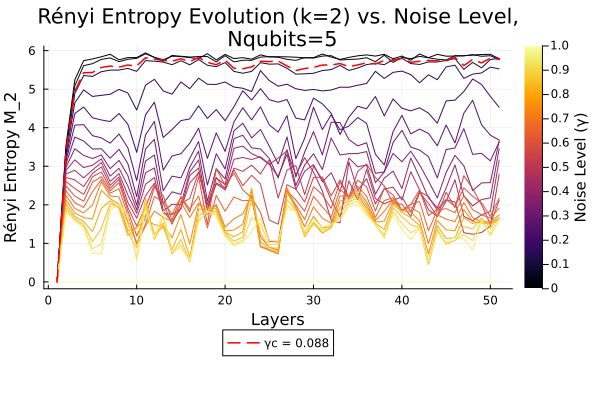

In [343]:
p = plot(
    title = "Rényi Entropy Evolution (k=$k) vs. Noise Level,\n Nqubits=$nqubits",
    xlabel = "Layers",
    ylabel = "Rényi Entropy M_$k",
    legend = :outerbottom,
    colorbar_title = "Noise Level (γ)",
    clims = (minimum(γ_list), maximum(γ_list)),
    color = :inferno)

for (i, entropy) in enumerate(renyi_entropy_list)
    plot!(p, entropy, line_z = γ_list[i], label = "", lw = 1)
end

plot!(p, renyi_entropy_c, label = "γc = $γc", line = (1.5, :dash, :red), line_z = nothing)

display(p)

In [348]:
for i in 1:length(γ_list)
  println("for γ=$(γ_list[i]) : truncation=$(truncations_pp[i])")
end

for γ=0.0 : truncation=(5, 1.0e-6)
for γ=0.05 : truncation=(5, 1.0e-6)
for γ=0.1 : truncation=(5, 1.0e-6)
for γ=0.15 : truncation=(5, 1.0e-6)
for γ=0.2 : truncation=(5, 1.0e-6)
for γ=0.25 : truncation=(5, 1.0e-6)
for γ=0.3 : truncation=(5, 1.0e-6)
for γ=0.35 : truncation=(5, 1.0e-6)
for γ=0.4 : truncation=(5, 1.0e-6)
for γ=0.45 : truncation=(5, 1.0e-6)
for γ=0.5 : truncation=(5, 1.0e-6)
for γ=0.55 : truncation=(5, 1.0e-6)
for γ=0.6 : truncation=(5, 1.0e-6)
for γ=0.65 : truncation=(5, 1.0e-6)
for γ=0.7 : truncation=(5, 1.0e-6)
for γ=0.75 : truncation=(5, 1.0e-6)
for γ=0.8 : truncation=(5, 1.0e-6)
for γ=0.85 : truncation=(5, 0.0001)
for γ=0.9 : truncation=(5, 1.0e-6)
for γ=0.95 : truncation=(5, 0.0001)
for γ=1.0 : truncation=(5, 0.0001)


---

## 3.2 MPO

In [349]:
operator_entanglement_list = Vector{Float64}[]
for γ in γ_list
  println("--- Noise parameter : gamma = $γ ---")
  Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, bond, γ)
  push!(operator_entanglement_list, result_mpo["S"])
end

--- Noise parameter : gamma = 0.0 ---
layer : 5 /50 complete
layer : 10 /50 complete
layer : 15 /50 complete
layer : 20 /50 complete
layer : 25 /50 complete
layer : 30 /50 complete
layer : 35 /50 complete
layer : 40 /50 complete
layer : 45 /50 complete
layer : 50 /50 complete
Time taken by mpo_functions.propagate_layerbylayer: 0.6424510478973389 seconds
--- Noise parameter : gamma = 0.05 ---
layer : 5 /50 complete
layer : 10 /50 complete
layer : 15 /50 complete
layer : 20 /50 complete
layer : 25 /50 complete
layer : 30 /50 complete
layer : 35 /50 complete
layer : 40 /50 complete
layer : 45 /50 complete
layer : 50 /50 complete
Time taken by mpo_functions.propagate_layerbylayer: 8.083521842956543 seconds
--- Noise parameter : gamma = 0.1 ---
layer : 5 /50 complete
layer : 10 /50 complete
layer : 15 /50 complete
layer : 20 /50 complete
layer : 25 /50 complete
layer : 30 /50 complete
layer : 35 /50 complete
layer : 40 /50 complete
layer : 45 /50 complete
layer : 50 /50 complete
Time taken 

In [350]:
Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, bond, γ=γc)
operator_entanglement_c = result_mpo["S"]
println("Test complete")

layer : 5 /50 complete
layer : 10 /50 complete
layer : 15 /50 complete
layer : 20 /50 complete
layer : 25 /50 complete
layer : 30 /50 complete
layer : 35 /50 complete
layer : 40 /50 complete
layer : 45 /50 complete
layer : 50 /50 complete
Time taken by mpo_functions.propagate_layerbylayer: 7.214569091796875 seconds
Test complete


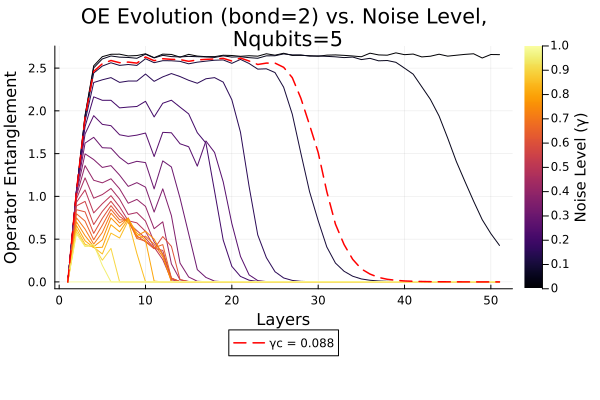

In [351]:
p = plot(
    title = "OE Evolution (bond=$bond) vs. Noise Level,\n Nqubits=$nqubits",
    xlabel = "Layers",
    ylabel = "Operator Entanglement",
    legend = :outerbottom,
    colorbar_title = "Noise Level (γ)",
    clims = (minimum(γ_list), maximum(γ_list)),
    color = :inferno)

for (i, entropy) in enumerate(operator_entanglement_list)
    plot!(p, entropy, line_z = γ_list[i], label = "", lw = 1)
end

plot!(p, operator_entanglement_c, label = "γc = $γc", line = (1.5, :dash, :red), line_z = nothing)

display(p)

---

## References

### Paper
- [Random Circuit](https://arxiv.org/abs/2603.20400)
- [Pauli Propagation](https://arxiv.org/abs/2505.21606)
- [PauliPropagation.jl](https://github.com/MSRudolph/PauliPropagation.jl)
- [Haar Random Matrix](https://arxiv.org/abs/math-ph/0609050)

### Julia Package
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)
- [LaTeXStrings documentation](https://juliapackages.com/p/latexstrings)

### Other
- Latex Tiks documentation https://www.overleaf.com/learn/latex/LaTeX_Graphics_using_TikZ%3A_A_Tutorial_for_Beginners_(Part_3)%E2%80%94Creating_Flowcharts



### memo
- https://github.com/MSRudolph/PauliPropagation.jl/blob/main/examples/introduction-example-error-mitigation.ipynb